# Simulate discrete events

In [1]:
import warnings
from copy import deepcopy
from tqdm import trange
from math import acos, cos, exp, pi, sin, sqrt, tan, atan, degrees
from statistics import geometric_mean

import matplotlib.pyplot as plt
import numpy as np
from colorspacious import cspace_convert
from ipywidgets import Button, HBox, IntSlider, FloatText, FloatSlider
from matplotlib import rcParams
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.markers import MarkerStyle
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, Normalize, to_rgb
from matplotlib.patches import Arc, Ellipse, FancyArrow
from numpy import (
    any,
    arccos,
    arctan2,
    arange,
    array,
    asarray,
    clip,
    column_stack,
    concatenate,
    deg2rad,
    degrees,
    empty_like,
    floor,
    round,
    hstack,
    linspace,
    unravel_index,
    newaxis,
    radians,
    sign,
)
from numpy.random import default_rng
from scipy.stats import gamma, kstest, ks_2samp, lognorm, probplot, shapiro, weibull_min, linregress
from scipy.optimize import minimize_scalar, root_scalar
from numpy.typing import ArrayLike
from typing import Any, Sequence, cast

In [2]:
from pNeuma_simulator import params
from pNeuma_simulator.initialization import PoissonDisc, equilibrium, ov, vo
from pNeuma_simulator.initialization.equilibrium import synthetic_fd
from pNeuma_simulator.shadowcasting.shadowcasting import shadowcasting

In [3]:
warnings.filterwarnings("ignore")
rcParams["animation.embed_limit"] = 2**128
rcParams.update(
    {
        "pdf.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
        "mathtext.fontset": "stix",
        "mathtext.default": "regular",
        "font.size": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.25,
        "xtick.major.width": 0.25,
        "ytick.major.width": 0.25,
        "xtick.minor.width": 0.25,
        "ytick.minor.width": 0.25,
    }
)
# LaTeX packages
plt.rc("text", usetex=False)
plt.rc(
    "text.latex",
    preamble=r"\usepackage{amsmath}",
)
plt.rc("text.latex", preamble=r"\usepackage{gensymb}")
dark_blue = "#1964B0"
dark_teal = "#008A69"
vermilion = "#DB5829"
orange = "#F4A637"
maroon = "#894B45"
dark_purple = "#882D71"
light_purple = "#D2BBD7"
grey = "#DEDEDE"
yellow = "#E9DC6D"
# RYG traffic colors
RAL_3020 = "#B81D13"
RAL_1023 = "#EFB700"
RAL_6024 = "#008450"

In [4]:
def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)  # type: ignore
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [5]:
%matplotlib inline
# Hex color stops: red → yellow → green
hex_colors = [RAL_3020, yellow, RAL_6024]
# Convert hex → RGB (0–1)
rgb = array([to_rgb(h) for h in hex_colors])
# Convert to Lab
lab = cspace_convert(rgb, "sRGB1", "CIELab")
# Interpolate smoothly in Lab
steps = 256
t = linspace(0, 1, steps)
# Quadratic Bézier interpolation between 3 colors
lab_interp = array([(1 - tt) ** 2 * lab[0] + 2 * (1 - tt) * tt * lab[1] + tt**2 * lab[2] for tt in t])
# Convert back to RGB
rgb_interp = cspace_convert(lab_interp, "CIELab", "sRGB1")
rgb_interp = clip(rgb_interp, 0, 1)
# Build colormap
cmap = ListedColormap(rgb_interp, name="RYG_Lab")

## Initialization

In [6]:
# centimeter to inch
cm = params.cm
# conversion factor
factor = params.factor
# simulation time step
dt = 1e-2  # params.dt
# lane width in meters
W = params.lane
# road length in meters
L = params.L
# car half-width in meters
w = params.car_w
# car half-length in meters
s = params.car_l
# moto half-width in meters
w_moto = params.moto_w
# moto half-length in meters
s_moto = params.moto_l

## Simulator

In [7]:
from pNeuma_simulator.gang.collision import collisions
from pNeuma_simulator.gang.particle import Particle
from pNeuma_simulator.gang.neighborhood import neighborhood
from pNeuma_simulator.contact_distance import ellipses
from pNeuma_simulator.utils import direction, projection, tangent_dist
from numba import jit
from numpy.linalg import norm
from numpy.typing import NDArray
from math import inf

In [8]:
@jit(nopython=True)
def infront(e_i, pos_i, pos_j):
    """
    Determines if a neighbor is in front of a given position.

    Args:
        e_i: The direction vector of the current position.
        pos_i: The current position.
        pos_j: The position of the neighbor.

    Returns:
        front: A boolean indicating if the neighbor is in front of the current position.
        e_i_j: The unit vector from the current position to the neighbor.
        s_i_j: The distance from the current position to the neighbor.
    """

    # Check if neighbor is in front
    r_i_j = pos_j - pos_i
    front = np.dot(e_i, r_i_j) > 0
    e_i_j = np.zeros(2)
    s_i_j = 0.0
    if front:
        # Distance from i to j
        s_i_j = float(norm(r_i_j))
        # Unit vector from i to j
        e_i_j = r_i_j / s_i_j
    return front, e_i_j, s_i_j

In [9]:
def ov(
    s: float | NDArray[np.floating], v: float | NDArray[np.floating], lam: float, v0: float, s0: float, T: float
) -> float | NDArray[np.floating]:
    x = v0 * (1 - np.exp((-lam / v0) * (s - s0 + T * v)))
    return x

In [10]:
prob = 0.03
p = prob * params.dt / 3
print(np.round(p, 6))

0.0001


In [11]:
116 / params.L

0.08055555555555556

In [12]:
def main(
    p=0.0001,
    seed=1,
    time_duration=10,
    brake_duration=3,
    discounting=0.6,
    n_cars=58,  # 232
    n_moto=0,
):

    COUNT = int(time_duration * 60 / params.dt)
    rng = np.random.default_rng(seed)
    T_a = 0.7993
    lam_a = 0.801
    v0_a = 11.36
    s0_a = 1.657
    lamprime_a = 1.085
    tauprime_a = 0.5969
    tau_a = 2.098

    sampler = PoissonDisc(
        n_cars,
        n_moto,
        lanes=[0],
        cell=params.cell,
        L=params.L,
        W=params.cell * 3,
        k=params.k,
        clearance=params.clearance,
        rng=rng,
    )
    samples, images = sampler.sample(rng)
    agents = samples
    brake_timer = np.zeros(len(agents), dtype=int)
    brake_acc = np.zeros(len(agents))
    l_agents = []
    # l_acc = []
    T = np.repeat(T_a, n_cars)
    lam = np.repeat(lam_a, n_cars)
    tau = np.repeat(tau_a, n_cars)
    v0 = np.repeat(v0_a, n_cars)
    s0 = np.repeat(s0_a, n_cars)
    lamprime = np.repeat(lamprime_a, n_cars)
    tauprime = np.repeat(tauprime_a, n_cars)
    for n, agent in enumerate(agents):
        # Reassign IDs
        agent.ID = n + 1
        agent.image = None
        agent.styles = None
        agent.tau = tau[n]
        agent.lam = lam[n]
        agent.v0 = v0[n]
        agent.s0 = s0[n]
    for t in range(COUNT - 1):
        rand = rng.random(len(agents))
        ######################
        # Periodic boundary
        ######################
        images = []
        serial_agents = []
        for agent in agents:
            if agent.x < -(params.L / 2 - (params.d_max + agent.l)):
                image = deepcopy(agent)
                image.x += params.L
                images.append(image)
                agent.image = image
            elif agent.x > params.L / 2 - (params.d_max + agent.l):
                image = deepcopy(agent)
                image.x -= params.L
                images.append(image)
                agent.image = image
            serial_agents.append(agent.x)
        l_agents.append(serial_agents)
        ##############################
        # Field of View analysis
        ##############################
        if t == 0:  # % skip == 0:
            for image in agents + images:
                cos_angle = -cos(image.theta)
                sin_angle = sin(image.theta)
                xc = params.xv - image.x
                yc = params.yv - image.y
                # https://stackoverflow.com/questions/37031356/
                xct = xc * cos_angle - yc * sin_angle
                yct = xc * sin_angle + yc * cos_angle
                rad = xct**2 / image.l**2 + yct**2 / image.w**2
                image.rad = rad
            matrices = []
            origins = []
            for agent in agents:
                matrix = np.zeros(params.shape)
                # top/bottom boundaries
                matrix[[0, -1], :] = 1
                for image in agents + images:
                    if image.ID != agent.ID:
                        assert image.rad is not None
                        matrix[image.rad < 1] = image.ID
                matrices.append(matrix)
                assert agent.rad is not None
                origin = unravel_index(agent.rad.argmin(), params.shape)
                origins.append(origin)
            tuples = []
            for i, j in zip(matrices, origins):
                shadowcast = shadowcasting(i, j, params.grid, params.L, params.d_max)
                tuples.append(shadowcast)
            for n, agent in enumerate(agents):
                assert tuples is not None
                interactions = tuples[n]
                agent.interactions = interactions.tolist()
        ################################
        # Dynamics
        ################################
        l_theta = []
        l_speed = []
        l_gap = []
        l_ttc = []
        for agent in agents:
            l_speed.append(agent.speed)
            theta_i = agent.theta
            l_theta.append(theta_i)
            # Semiaxis dimensions of i
            l_i, w_i = agent.l, agent.w
            # Absolute position of i
            pos_i = agent.pos
            x_i, y_i = pos_i
            interactions = agent.interactions
            if len(interactions) > 0:
                gaps = []
                neighbors = neighborhood(agent, agents)
                # Direction vector and its normal
                e_i, e_i_n = direction(theta_i)
                front_neighbors = []
                for neighbor in neighbors:
                    # Semiaxis dimensions of j
                    l_j, w_j = neighbor.l, neighbor.w
                    # Absolute position of j
                    pos_j = neighbor.pos
                    x_j, y_j = pos_j
                    # Direction of j
                    theta_j = neighbor.theta
                    # Check if neighbor is in front
                    front, e_i_j, s_i_j = infront(e_i, pos_i, pos_j)
                    if front:
                        front_neighbors.append(neighbor)
                        # Distance from tangent parallel to i
                        k_h = tangent_dist(theta_j, theta_i, l_j, w_j)
                        proj = projection(e_i_n, e_i_j, s_i_j)
                        # This is extremely important!!!
                        if proj <= params.scaling * w_i + k_h:
                            # Distance of closest approach between i and j
                            if proj == 0:
                                min_d = l_i + l_j
                            else:
                                min_d = ellipses(
                                    l_j,
                                    w_j,
                                    l_i,
                                    w_i,
                                    x_j,
                                    y_j,
                                    x_i,
                                    y_i,
                                    theta_j,
                                    theta_i,
                                )
                            gap = s_i_j - min_d
                        else:
                            gap = inf
                    else:
                        gap = inf
                    gaps.append(gap)
                if np.isfinite(gaps).sum() > 0:
                    leader = neighbors[np.argmin(gaps)]
                    gap = min(gaps)
                    agent.leader = leader.ID
                    agent.gap = gap
                    # actual time to collision
                    assert agent.speed is not None
                    ttc = collisions(agent, agent.speed, 0, [leader])
                    agent.ttc = ttc
                else:
                    agent.leader = None
                    agent.gap = params.d_max
            else:
                agent.leader = None
                agent.gap = params.d_max
            assert agent.gap is not None
            if agent.gap <= 0:
                print("Accident occurred")
            # Retrieve inverse ttc
            if agent.ttc is None:
                ttc = -1
            else:
                ttc = agent.ttc
            l_ttc.append(ttc)
            l_gap.append(agent.gap)
        # Stochastic component
        ttc = np.array(l_ttc)
        gaps = np.array(l_gap)
        DeltaV = gaps / ttc
        V = np.array(l_speed)
        OV = np.array(ov(gaps, V, lam[0], v0[0], s0[0], T[0]))
        # --- deterministic acceleration ---
        acc_det = (OV - V) / tau - (np.maximum(0, DeltaV) / tauprime) * (np.exp(-(lamprime / v0) * (gaps - s0 + T * V)))
        # --------------------------------------------------
        # 1. Decrement timers from previous timestep
        # --------------------------------------------------
        brake_timer[brake_timer > 0] -= 1
        # --------------------------------------------------
        # 2. Trigger new braking events
        # --------------------------------------------------
        new_brake = (brake_timer == 0) & (rand < p)
        if np.any(new_brake):
            idx = np.where(new_brake)[0]
            durations = np.repeat(brake_duration, len(idx))
            brake_timer[idx] = np.ceil(durations / params.dt).astype(int)
            brake_acc[idx] = (discounting * OV[idx] - V[idx]) / tau[idx] - (
                (np.maximum(0, DeltaV)[idx]) / tauprime[idx]
            ) * (np.exp(-(lamprime[idx] / v0[idx]) * (gaps[idx] - s0[idx] + T[idx] * V[idx])))
            # l_acc.extend(brake_acc[idx])
        # --------------------------------------------------
        # 3. Recompute active braking AFTER timer update
        # --------------------------------------------------
        braking = brake_timer > 0
        # --------------------------------------------------
        # 4. Compute acceleration
        # --------------------------------------------------
        acc = np.where(braking, brake_acc, acc_det)
        # --------------------------------------------------
        # 5. Update velocity
        # --------------------------------------------------
        new_V = np.maximum(V + acc * params.dt, 0.0)
        ##################################
        # Advance the simulation
        ##################################
        for n, agent in enumerate(agents):
            agent.advance(params.dt, new_V[n])
            agent.image = None
            agent.trajectory = None
    return l_agents  # , l_acc

In [13]:
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from joblib.externals.loky import get_reusable_executor

In [14]:
import json
import os
import zipfile

In [15]:
p = 0.0001
time_duration = 20  # 10
brake_duration = 3
discounting = 0.6
n_cars = 116  # 58
n_moto = 0
path = f"./output/sketches/nasch_INM_{round(p, 4)}_{time_duration}_{brake_duration}_{discounting}_{n_cars}"
path

'./output/sketches/nasch_INM_0.0001_20_3_0.6_116'

In [16]:
epochs = 128
seeds = np.arange(epochs)
n_jobs = 32

zip_path = f"{path}.zip"
jsonl_name = f"{os.path.basename(path)}.jsonl"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    with zf.open(jsonl_name, "w", force_zip64=True) as f:
        for i in range(0, epochs, n_jobs):
            batch = seeds[i : i + n_jobs]
            with Parallel(n_jobs=n_jobs) as parallel:
                items = parallel(
                    delayed(main)(
                        p=p,
                        seed=seed,
                        time_duration=time_duration,
                        brake_duration=brake_duration,
                        discounting=discounting,
                        n_cars=n_cars,
                        n_moto=n_moto,
                    )
                    for seed in batch
                )
                # https://stackoverflow.com/questions/67495271/
                get_reusable_executor().shutdown(wait=True)
            if items:
                # write batch immediately, then discard
                for item in items:
                    f.write((json.dumps(item) + "\n").encode())

# Finite size scaling analysis

In [17]:
def eulerian_surface_from_passages(positions, L, dx=7.0):
    T, N = positions.shape
    M = int(np.ceil(L / dx))

    h = np.zeros((T, M), dtype=np.int32)

    prev_cells = np.floor(np.mod(positions[0], L) / dx).astype(int) % M

    for t in range(1, T):
        curr_cells = np.floor(np.mod(positions[t], L) / dx).astype(int) % M

        h[t] = h[t - 1]

        for j in range(N):
            c0 = prev_cells[j]
            c1 = curr_cells[j]
            crossed = (c1 - c0) % M

            for k in range(1, crossed + 1):
                h[t, (c0 + k) % M] += 1

        prev_cells = curr_cells

    x = (np.arange(M) + 0.5) * dx
    x = np.minimum(x, L - 0.5 * dx)
    return x, h

In [18]:
def interface_width_series(H):
    H_mean = np.mean(H, axis=1, keepdims=True)  # mean over spatial indices
    W = np.sqrt(np.mean((H - H_mean) ** 2, axis=1))
    return W

In [53]:
def bootstrap_mean_ci(data, n_boot=1000, ci=95, random_state=None):
    rng = np.random.default_rng(random_state)

    n_realizations, n_time = data.shape

    boot_means = np.empty((n_boot, n_time))

    for i in range(n_boot):
        idx = rng.integers(0, n_realizations, size=n_realizations)
        sample = data[idx, :]
        boot_means[i] = sample.mean(axis=0)

    alpha = (100 - ci) / 2
    lower = np.percentile(boot_means, alpha, axis=0)
    upper = np.percentile(boot_means, 100 - alpha, axis=0)

    return lower, upper

In [19]:
l_W = []
items = []
with zipfile.ZipFile(f"{path}.zip", "r") as ziph:
    for filename in ziph.namelist():
        if filename.endswith(".jsonl"):
            with ziph.open(filename, "r") as openfile:
                for i, line in enumerate(tqdm(openfile)):
                    item = json.loads(line)
                    # items.append(item)
                    n_steps = len(item)
                    n_cars = len(item[0])
                    positions = np.zeros((n_steps, n_cars))
                    timestamps = np.arange(0, n_steps) * dt
                    for t in range(n_steps):
                        idx = 0
                        for n in range(n_cars):
                            x_a = item[t][n]
                            positions[t, idx] = x_a
                            idx += 1
                    _, h = eulerian_surface_from_passages(
                        positions=positions,
                        L=params.L,
                        dx=9,
                    )
                    W = interface_width_series(h)
                    l_W.append(W)

0it [00:00, ?it/s]

In [20]:
np.save(f"{path}.npy", l_W)

In [ ]:
path = f"./output/sketches/nasch_INM_{round(p, 4)}_20_{brake_duration}_{discounting}_116"
l_W = np.load(f"{path}.npy")
W_average_116 = np.mean(
    l_W,
    axis=0,
)
lower_116, upper_116 = bootstrap_mean_ci(l_W, n_boot=1000)

In [57]:
path = f"./output/sketches/nasch_INM_{round(p, 4)}_10_{brake_duration}_{discounting}_58"
l_W = np.load(f"{path}.npy")
W_average_58 = np.mean(
    l_W,
    axis=0,
)
lower_58, upper_58 = bootstrap_mean_ci(l_W, n_boot=1000)

In [41]:
n_cars = 232
W_series_L2 = np.load(f"./output/sketches/nasch_INM_2_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R2 = np.load(f"./output/sketches/nasch_INM_2_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L3 = np.load(f"./output/sketches/nasch_INM_3_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R3 = np.load(f"./output/sketches/nasch_INM_3_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L4 = np.load(f"./output/sketches/nasch_INM_4_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R4 = np.load(f"./output/sketches/nasch_INM_4_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L5 = np.load(f"./output/sketches/nasch_INM_5_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R5 = np.load(f"./output/sketches/nasch_INM_5_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L6 = np.load(f"./output/sketches/nasch_INM_6_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R6 = np.load(f"./output/sketches/nasch_INM_6_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L7 = np.load(f"./output/sketches/nasch_INM_7_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R7 = np.load(f"./output/sketches/nasch_INM_7_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L8 = np.load(f"./output/sketches/nasch_INM_8_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R8 = np.load(f"./output/sketches/nasch_INM_8_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L9 = np.load(f"./output/sketches/nasch_INM_9_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R9 = np.load(f"./output/sketches/nasch_INM_9_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L10 = np.load(f"./output/sketches/nasch_INM_10_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R10 = np.load(f"./output/sketches/nasch_INM_10_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L11 = np.load(f"./output/sketches/nasch_INM_11_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R11 = np.load(f"./output/sketches/nasch_INM_11_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L12 = np.load(f"./output/sketches/nasch_INM_12_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R12 = np.load(f"./output/sketches/nasch_INM_12_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L13 = np.load(f"./output/sketches/nasch_INM_13_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R13 = np.load(f"./output/sketches/nasch_INM_13_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L14 = np.load(f"./output/sketches/nasch_INM_14_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R14 = np.load(f"./output/sketches/nasch_INM_14_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L15 = np.load(f"./output/sketches/nasch_INM_15_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy")
W_series_R15 = np.load(f"./output/sketches/nasch_INM_15_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy")
W_series_L100 = np.load(
    f"./output/sketches/nasch_INM_100_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WL.npy"
)
W_series_R100 = np.load(
    f"./output/sketches/nasch_INM_100_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}_WR.npy"
)
W_average = np.mean(
    [
        W_series_L2,
        W_series_R2,
        W_series_L3,
        W_series_R3,
        W_series_L4,
        W_series_R4,
        W_series_L5,
        W_series_R5,
        W_series_L6,
        W_series_R6,
        W_series_L7,
        W_series_R7,
        W_series_L8,
        W_series_R8,
        W_series_L9,
        W_series_R9,
        W_series_L10,
        W_series_R10,
        W_series_L11,
        W_series_R11,
        W_series_L12,
        W_series_R12,
        W_series_L13,
        W_series_R13,
        W_series_L14,
        W_series_R14,
        W_series_L15,
        W_series_R15,
    ],
    axis=0,
)
W_average_45 = np.mean(
    [W_series_L100, W_series_R100],
    axis=0,
)

In [64]:
W_average_232 = np.mean(
    [
        W_series_L2,
        W_series_R2,
        W_series_L3,
        W_series_R3,
        W_series_L4,
        W_series_R4,
        W_series_L5,
        W_series_R5,
        W_series_L6,
        W_series_R6,
        W_series_L7,
        W_series_R7,
        W_series_L8,
        W_series_R8,
        W_series_L9,
        W_series_R9,
        W_series_L10,
        W_series_R10,
        W_series_L11,
        W_series_R11,
        W_series_L12,
        W_series_R12,
        W_series_L13,
        W_series_R13,
        W_series_L14,
        W_series_R14,
        W_series_L15,
        W_series_R15,
    ],
    axis=0,
)
lower_232, upper_232 = bootstrap_mean_ci(
    np.array(
        [
            W_series_L2,
            W_series_R2,
            W_series_L3,
            W_series_R3,
            W_series_L4,
            W_series_R4,
            W_series_L5,
            W_series_R5,
            W_series_L6,
            W_series_R6,
            W_series_L7,
            W_series_R7,
            W_series_L8,
            W_series_R8,
            W_series_L9,
            W_series_R9,
            W_series_L10,
            W_series_R10,
            W_series_L11,
            W_series_R11,
            W_series_L12,
            W_series_R12,
            W_series_L13,
            W_series_R13,
            W_series_L14,
            W_series_R14,
            W_series_L15,
            W_series_R15,
        ]
    ),
    n_boot=1000,
)

In [65]:
from matplotlib.ticker import LogFormatterSciNotation

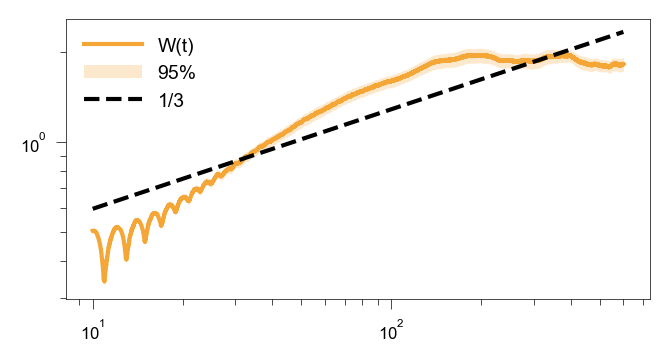

In [66]:
# Assume W_series is already computed and has shape (T,)
start = 1000
t = np.arange(0, len(W_average_58)) * dt

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t[start:], W_average_58[start:], label="W(t)", c=orange)
ax.fill_between(
    t[start:],
    lower_58[start:],
    upper_58[start:],
    color=orange,
    alpha=0.25,
    linewidth=0,
    label="95%",
)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_average_58[start:]) - (1 / 3) * np.log(t[start:]))
ref_line = np.exp(logA) * t[start:] ** (1 / 3)
plt.loglog(t[start:], ref_line, "--", label="1/3", c="k")

ax.yaxis.set_minor_formatter(
    LogFormatterSciNotation(
        base=10,
        labelOnlyBase=True,
        minor_thresholds=(np.inf, np.inf),
    )
)

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

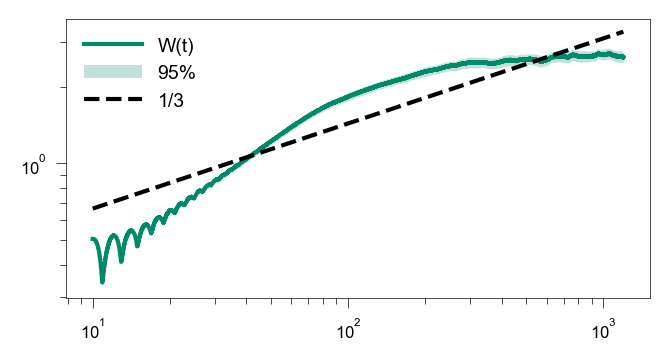

In [67]:
# Assume W_series is already computed and has shape (T,)
start = 1000
t = np.arange(0, len(W_average_116)) * dt

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t[start:], W_average_116[start:], label="W(t)", c=dark_teal)
ax.fill_between(
    t[start:],
    lower_116[start:],
    upper_116[start:],
    color=dark_teal,
    alpha=0.25,
    linewidth=0,
    label="95%",
)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_average_116[start:]) - (1 / 3) * np.log(t[start:]))
ref_line = np.exp(logA) * t[start:] ** (1 / 3)
plt.loglog(t[start:], ref_line, "--", label="1/3", c="k")

ax.yaxis.set_minor_formatter(
    LogFormatterSciNotation(
        base=10,
        labelOnlyBase=True,
        minor_thresholds=(np.inf, np.inf),
    )
)

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

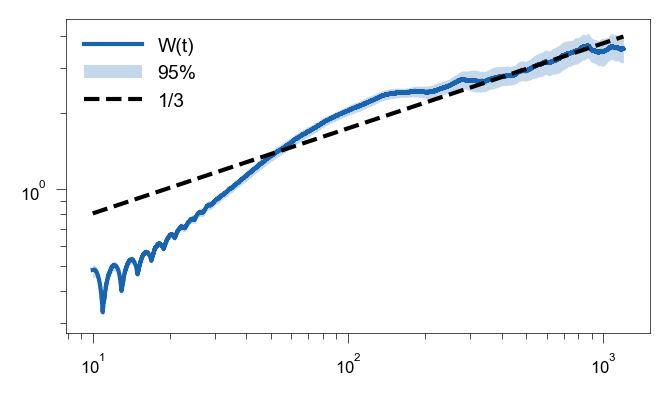

In [75]:
# Assume W_series is already computed and has shape (T,)
start = 1000
t = np.arange(0, len(W_average_232)) * dt

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t[start:], W_average_232[start:], label="W(t)", c=dark_blue)
ax.fill_between(
    t[start:],
    lower_232[start:],
    upper_232[start:],
    color=dark_blue,
    alpha=0.25,
    linewidth=0,
    label="95%",
)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_average_232[start:]) - (1 / 3) * np.log(t[start:]))
ref_line = np.exp(logA) * t[start:] ** (1 / 3)
plt.loglog(t[start:], ref_line, "--", label="1/3", c="k")

ax.yaxis.set_minor_formatter(
    LogFormatterSciNotation(
        base=10,
        labelOnlyBase=True,
        minor_thresholds=(np.inf, np.inf),
    )
)

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()

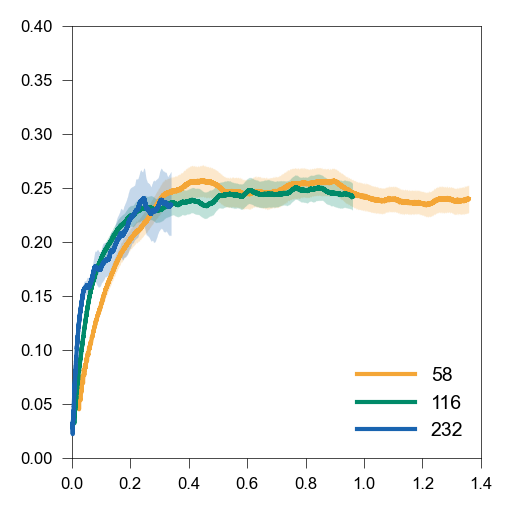

In [82]:
fig, ax = plt.subplots(figsize=(6 * params.cm, 6 * params.cm), dpi=200)
## Assume W_series is already computed and has shape (T,)
start = 1000
n_cars = 58
W_FV58 = W_average_58[start:] / (n_cars ** (1 / 2))
lower_FV58 = lower_58[start:] / (n_cars ** (1 / 2))
upper_FV58 = upper_58[start:] / (n_cars ** (1 / 2))
t_58 = np.arange(0, len(W_average_58)) * dt
t_FV58 = t_58[start:] / (n_cars ** (3 / 2))
ax.fill_between(
    t_FV58,
    lower_FV58,
    upper_FV58,
    color=orange,
    alpha=0.25,
    linewidth=0,
)
plt.plot(t_FV58, W_FV58, c=orange, label="58")
n_cars = 116
W_FV116 = W_average_116[start:] / (n_cars ** (1 / 2))
lower_FV116 = lower_116[start:] / (n_cars ** (1 / 2))
upper_FV116 = upper_116[start:] / (n_cars ** (1 / 2))
t_116 = np.arange(0, len(W_average_116)) * dt
t_FV116 = t_116[start:] / (n_cars ** (3 / 2))
ax.fill_between(
    t_FV116,
    lower_FV116,
    upper_FV116,
    color=dark_teal,
    alpha=0.25,
    linewidth=0,
)
plt.plot(t_FV116, W_FV116, c=dark_teal, label="116")
n_cars = 232
W_FV232 = W_average_232[start:] / (n_cars ** (1 / 2))
lower_FV232 = lower_232[start:] / (n_cars ** (1 / 2))
upper_FV232 = upper_232[start:] / (n_cars ** (1 / 2))
t_232 = np.arange(0, len(W_average_232)) * dt
t_FV232 = t_232[start:] / (n_cars ** (3 / 2))
ax.fill_between(
    t_FV232,
    lower_FV232,
    upper_FV232,
    color=dark_blue,
    alpha=0.25,
    linewidth=0,
)
plt.plot(t_FV232, W_FV232, c=dark_blue, zorder=100, clip_on=False, label="232")
ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=4,
)
ax.set_xlim(0, 1.4)
ax.set_ylim(0.0, 0.4)
plt.tight_layout(pad=0)
plt.show()

In [46]:
# path = f"./output/sketches/nasch_INM_{seed}_{np.round(brake_duration,2)}_{discounting}_{p}_{n_cars}.jsonl"

In [47]:
# with open(path, "r") as infile:
#    l_agents = json.load(infile)
# l_agents[10][0]

In [247]:
if items:
    l_agents = items[4]

In [248]:
n_steps = len(l_agents)
positions = np.zeros((n_steps, n_cars))
# velocities = np.zeros((n_steps, n_cars))
# spacings = np.zeros((n_steps, n_cars))
timestamps = np.arange(0, n_steps) * dt
for t in range(n_steps):
    idx = 0
    for n in range(n_cars):
        x_a = l_agents[t][n]  # ["pos"][0]
        # y_a = l_agents[t][n]["pos"][1]
        # v_a = l_agents[t][n]["speed"]
        # s_a = l_agents[t][n]["gap"]
        # if y_a > 0:
        positions[t, idx] = x_a
        #    velocities[t, idx] = v_a
        #    spacings[t, idx] = s_a
        idx += 1
    # sanity check: make sure we filled exactly n_cars per row
    if idx != n_cars:
        raise ValueError(f"Expected {n_cars} vehicles at t={t}, got {idx}")

In [250]:
x, h = eulerian_surface_from_passages(
    positions=positions,
    L=params.L,
    dx=9,
)

In [251]:
N = h

In [27]:
from palettable.colorbrewer.diverging import Spectral_8  # type: ignore
from palettable.colorbrewer.sequential import GnBu_9, Blues_9  # type: ignore

cmap = Spectral_8.mpl_colormap  # type: ignore

In [253]:
# _ = plt.imshow(N, aspect="auto", cmap=Spectral_8.mpl_colormap, origin="lower")

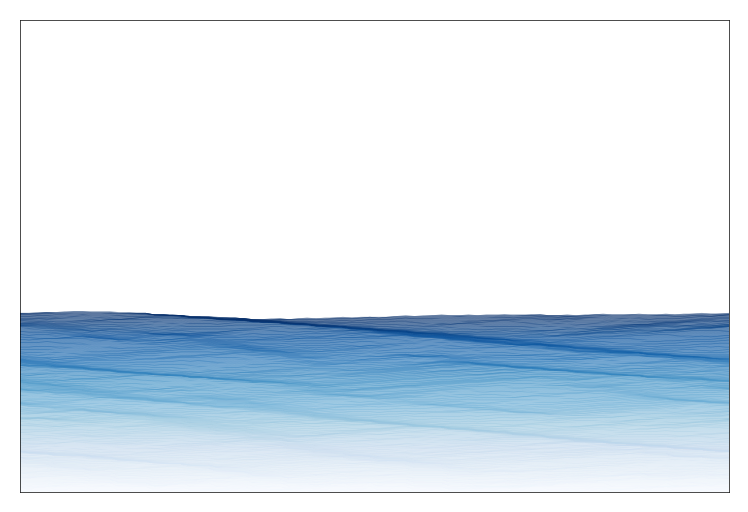

In [254]:
# Example parameters
indices = np.arange(0, N.shape[0], 100)  # same as your slicing
colors = Blues_9.mpl_colormap(np.linspace(0, 1, len(indices)))  # gradient across indices
fig, ax = plt.subplots(figsize=(9 * params.cm, 6 * params.cm), dpi=200)
for i, idx in enumerate(indices):
    ax.plot(N[idx, :], color=colors[i], lw=0.25, alpha=0.5)
ax.set_xlim(0, N.shape[1] - 1)
ax.set_ylim(0, 600)
# Remove all ticks and numbers
ax.set_xticks([])  # remove x-axis ticks
ax.set_yticks([])  # remove y-axis ticks
ax.set_xticklabels([])  # remove x-axis labels
ax.set_yticklabels([])  # remove y-axis labels
plt.tight_layout(pad=0)
plt.show()

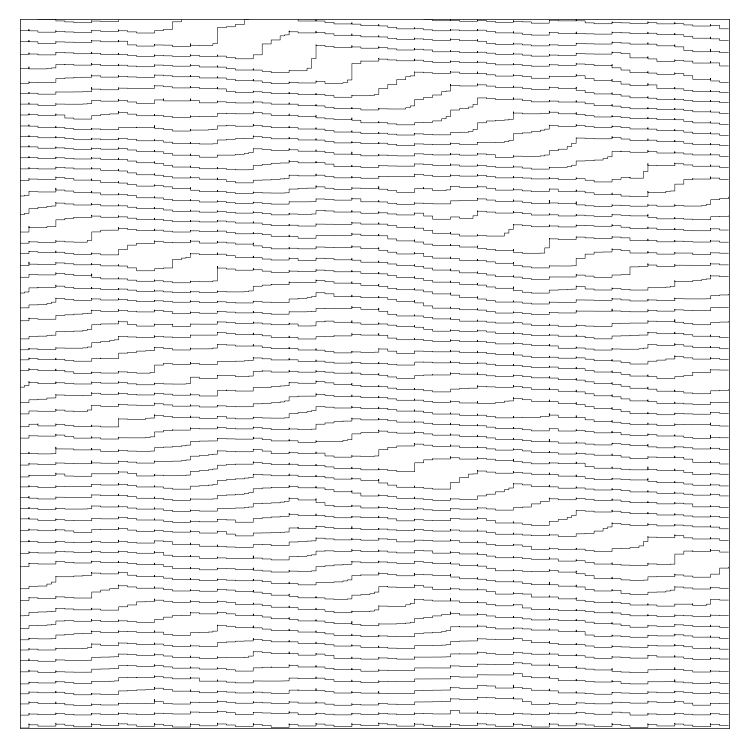

In [255]:
fig, ax = plt.subplots(figsize=(9 * params.cm, 9 * params.cm), dpi=200)

# Assuming N_fluct is a 2D array
# Create coordinate grids for plotting
y = np.arange(N.shape[0])
x = np.arange(N.shape[1])
X, Y = np.meshgrid(x, y)

# Plot black contours
# Number of contour levels you want
num_contours = 60  # <-- change this to control number of contours

# Plot contours
contours = ax.contour(
    X,
    Y,
    N,  # your array (negated if needed)
    levels=num_contours,  # number of contour levels
    colors="black",  # black lines
    linewidths=0.2,  # line width
)
# ax.set_title("Contour Plot of N_fluct")
# Remove all ticks and numbers
ax.set_xticks([])  # remove x-axis ticks
ax.set_yticks([])  # remove y-axis ticks
ax.set_xticklabels([])  # remove x-axis labels
ax.set_yticklabels([])  # remove y-axis labels
plt.tight_layout(pad=0)
plt.show()

In [256]:
np.shape(N)

(59999, 80)

In [258]:
W_series = interface_width_series(N)

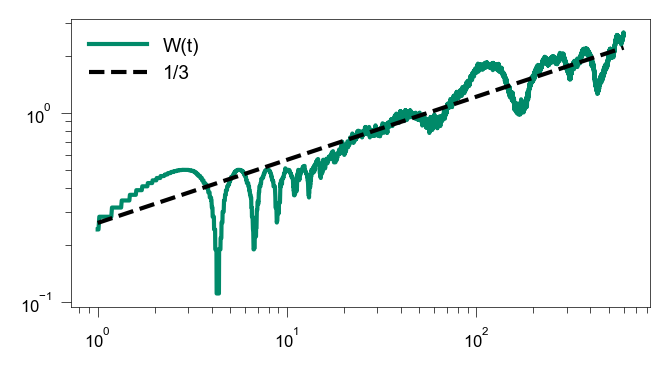

In [259]:
# Assume W_series is already computed and has shape (T,)
start = 100
W_late = W_series[start:]  # take late-time part
t = np.arange(0, len(W_series)) * dt
t_late = t[start:]
# t = np.arange(start, start + len(W_late))  # corresponding time steps

fig, ax = plt.subplots(figsize=(8 * params.cm, 7 * params.cm), dpi=200)
ax.set_aspect("equal")
plt.loglog(t_late, W_late, label="W(t)", c=dark_teal)

# Add reference line with slope 1/3 (fitted prefactor)
logA = np.mean(np.log(W_late) - (1 / 3) * np.log(t_late))
ref_line = np.exp(logA) * t_late ** (1 / 3)
plt.loglog(t_late, ref_line, "--", label="1/3", c="k")

# ax.yaxis.set_minor_formatter(
#    LogFormatterSciNotation(
#        base=10,
#        labelOnlyBase=False,
#        minor_thresholds=(np.inf, np.inf),
#    )
# )

ax.legend(
    frameon=False,
    handlelength=3,
    fontsize=7,
    loc=0,
)

plt.tight_layout(pad=0)
plt.show()